In [335]:
import joblib
import csv
import pandas as pd
import glob
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import geopandas as gpd

from sklearn.decomposition import PCA
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.mask import mask
from rasterio import features
from collections import defaultdict

from skimage import morphology
from skimage.measure import label, regionprops
from skimage.morphology import disk

In [336]:
# Reload the trained model
model_path = "rf_classifier_model31DEC.pkl"
rf = joblib.load(model_path)
print(f"Model loaded from {model_path}")

Model loaded from rf_classifier_model31DEC.pkl


In [337]:
# Set paths to image directory and list all images
year = "2024"
image_dir = rf"C:\Users\WilsonSIRL5-MCY-E113\Documents\White glacier ML\WhiteSentinel2file_{year}"
image_files = glob.glob(os.path.join(image_dir, "*.tif"))
glacier_outline = gpd.read_file(r"C:\Users\WilsonSIRL5-MCY-E113\Documents\White glacier ML\White outline\glims_polygons.shp")
# Load the DEM
dem_path = r"C:\Users\WilsonSIRL5-MCY-E113\Documents\White glacier ML\whiteglacierDEM_reprojected.tif"
pca = PCA(n_components=2)

In [338]:
# Classify a new image using the trained Random Forest model
def classify_image(image_path, model, pca_transformer):
    # Read the new image using Rasterio
    with rasterio.open(image_path) as img:
        r = img.read(1)
        g = img.read(2)
        b = img.read(3)
        ir = img.read(4)

    # Stack bands into a single array
    stacked = np.dstack((r, g, b, ir)).reshape((-1, 4))

    # Apply PCA transformation
    stacked_pca = pca.fit_transform(stacked)

    # Predict labels for the new image
    predicted_labels = model.predict(stacked_pca)
    
    # Reshape to original image shape
    label_img = predicted_labels.reshape(img.height, img.width)
    
    return label_img

# Function to classify image and calculate SCR
def classify_and_calculate_scr(image_path, model, pca_transformer):
    # Classify the image
    classified_image = classify_image(image_path, model, pca_transformer)

    # Count the classified pixels for snow, ice, and ground
    unique, counts = np.unique(classified_image, return_counts=True)
    pixel_counts = dict(zip(unique, counts))

    # Each pixel represents a 10m x 10m area (100 square meters)
    pixel_area = 100  # in square meters

    # Calculate areal extent
    ice_area = pixel_counts.get(2, 0) * pixel_area  # Assuming 2 is ice
    snow_area = (pixel_counts.get(1, 0) * pixel_area) + (pixel_counts.get(3, 0) * pixel_area) # Assuming 1 +3 is snow

    total_area = ice_area + snow_area

    # Calculate Snow Cover Ratio (SCR)
    scr = snow_area / total_area if total_area != 0 else 0

    return classified_image, scr


# Function to calculate the snow cover ratio for a given image
def find_potential_snow_line(df, threshold=0.5, min_consecutive_bins=3):
    # Ensure proper iteration
    df = df.reset_index(drop=True)
    
    potential_snow_line = None
    max_consecutive = 0

    # Primary check: look for sequences that meet the minimum consecutive bins requirement
    for i in range(len(df)):
        if df.loc[i, 'Snow_Cover_Ratio'] > threshold:
            consecutive_count = 1
            j = i + 1
            while j < len(df) and df.loc[j, 'Snow_Cover_Ratio'] > threshold:
                consecutive_count += 1
                j += 1

            if consecutive_count >= min_consecutive_bins and consecutive_count > max_consecutive:
                potential_snow_line = df.loc[i, 'Elevation_Bin']
                max_consecutive = consecutive_count

    # Fallback: if no sequence meets the minimum, use the bin with the maximum consecutive snowy bins
    if potential_snow_line is None:
        for i in range(len(df)):
            if df.loc[i, 'Snow_Cover_Ratio'] > threshold:
                consecutive_count = 1
                j = i + 1
                while j < len(df) and df.loc[j, 'Snow_Cover_Ratio'] > threshold:
                    consecutive_count += 1
                    j += 1

                if consecutive_count > max_consecutive:
                    potential_snow_line = df.loc[i, 'Elevation_Bin']
                    max_consecutive = consecutive_count

    return potential_snow_line

In [339]:
# Create a CSV file to store the results
output_csv_file = rf"{year}_glacier_classification_summary.csv"

with open(output_csv_file, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Date", "Ice Area (km²)", "Snow Area (km²)", "Ground Area (km²)", "Snow Cover Ratio (SCR)"])
    
    for img_path in image_files:
        # Extract the date from the filename
        file_name = os.path.basename(img_path)
        date_str = file_name.split('_')[1].split('(')[0]

        # Classify the image and calculate SCR
        classified_image, scr = classify_and_calculate_scr(img_path, rf, pca)

        # Count the classified pixels for snow, ice, and ground
        unique, counts = np.unique(classified_image, return_counts=True)
        pixel_counts = dict(zip(unique, counts))

        # Each pixel represents a 10m x 10m area (100 square meters)
        pixel_area = 100  # in square meters

        # Calculate areal extent
        ice_area = pixel_counts.get(2, 0) * pixel_area  # Assuming 2 is ice
        snow_area = (pixel_counts.get(1, 0) * pixel_area) + (pixel_counts.get(3, 0) * pixel_area) # Assuming 1 + 3 is snow
        ground_area = pixel_counts.get(0, 0) * pixel_area  # Assuming 0 is ground

        # Write results to CSV
        writer.writerow([date_str, ice_area / 1e6, snow_area / 1e6, ground_area / 1e6, scr])

print(f"Results saved to {output_csv_file}")

Results saved to 2024_glacier_classification_summary.csv


In [340]:
# Find the image with the lowest SCR
lowest_scr = float('inf')
lowest_scr_image_path = None
lowest_scr_image = None

for img_path in image_files:
    _, scr = classify_and_calculate_scr(img_path, rf, pca)
    if scr < lowest_scr:
        lowest_scr = scr
        lowest_scr_image_path = img_path

# Process the image with the lowest SCR
classified_image, _ = classify_and_calculate_scr(lowest_scr_image_path, rf, pca)

# Extract the date and SCR value for the lowest SCR image
lowest_scr_date = pd.to_datetime(os.path.basename(lowest_scr_image_path).split("_")[1].split(".")[0].split("(")[0], format='%Y-%m-%d', errors='coerce')

lowest_scr_value = lowest_scr

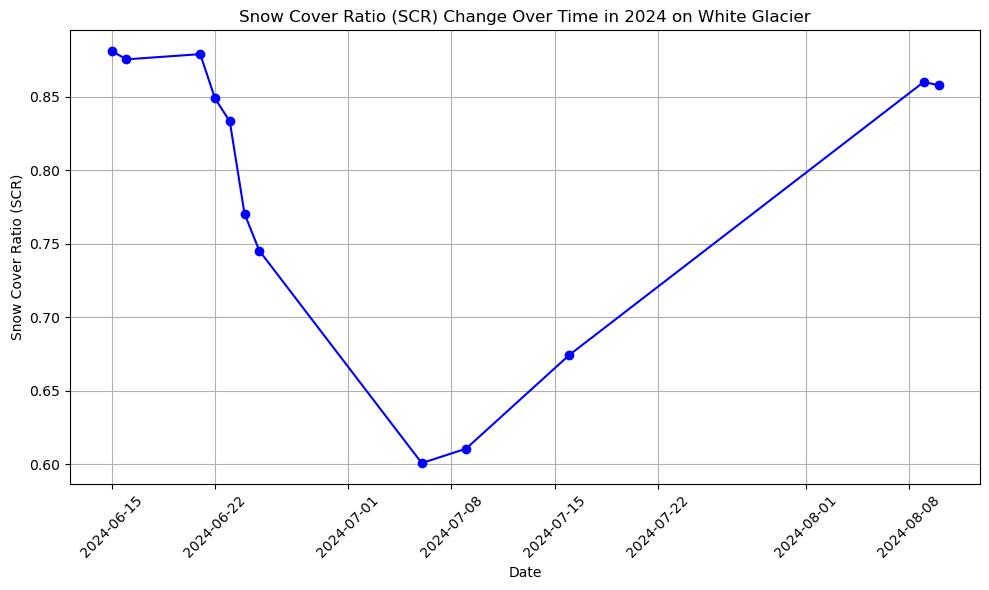

In [341]:
# Assuming results is a list of tuples with (date_str, scr)
results = []

for img_path in image_files:
    # Extract the date from the filename
    file_name = os.path.basename(img_path)
    date_str = file_name.split('_')[1].split('.')[0]

    # Classify the image and calculate SCR
    _, scr = classify_and_calculate_scr(img_path, rf, pca)

    # Append the date and SCR to the results list
    results.append((date_str, scr))

# Visualize the SCR change by date
results_df = pd.DataFrame(results, columns=["Date", "SCR"])
results_df["Date"] = pd.to_datetime(results_df["Date"], format='%Y-%m-%d', errors='coerce')
results_df = results_df.dropna().sort_values(by="Date")

plt.figure(figsize=(10, 6))
plt.plot(results_df["Date"], results_df["SCR"], marker='o', linestyle='-', color='b')
plt.xlabel('Date')
plt.ylabel('Snow Cover Ratio (SCR)')
plt.title(f'Snow Cover Ratio (SCR) Change Over Time in {year} on White Glacier')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

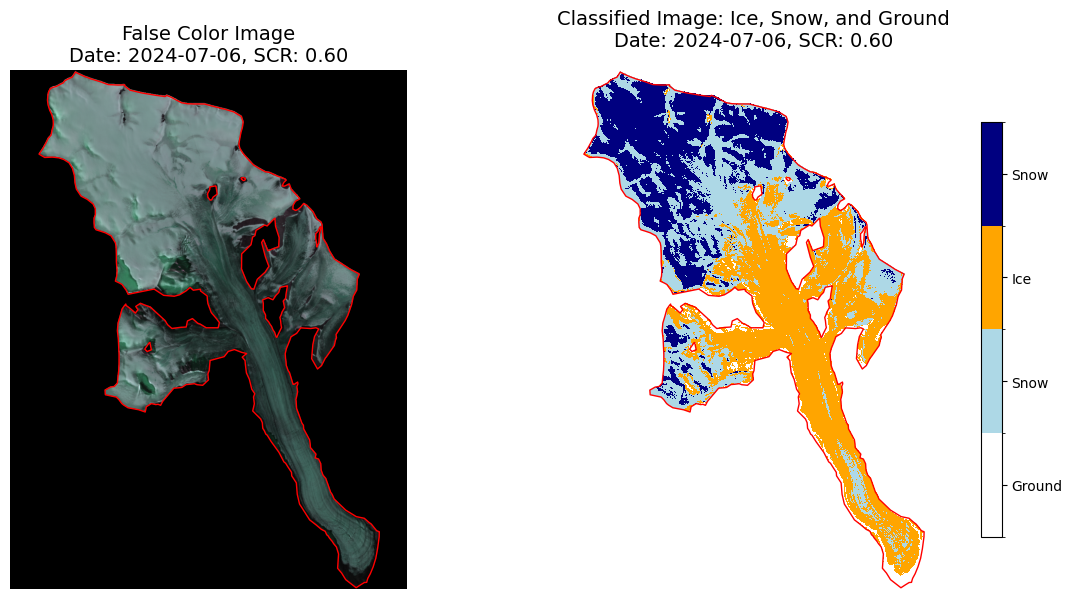

In [342]:
# Open and read the original image with the lowest SCR
with rasterio.open(lowest_scr_image_path) as src:
    band_1 = src.read(1)  # Blue
    band_2 = src.read(2)  # Green
    band_3 = src.read(3)  # Red
    band_4 = src.read(4)  # Near-Infrared
    sentinel_crs = src.crs
    sentinel_extent = src.bounds

# Stack the bands to create a false color image (NIR, Green, Red)
false_color = np.dstack((band_4, band_2, band_3))

# Normalize to 0-255 scale for enhanced visualization
false_color = (false_color - false_color.min()) / (false_color.max() - false_color.min()) * 255
false_color = false_color.astype(np.uint8)

# Reproject the glacier outline to match the Sentinel-2 image CRS
glacier_outline = glacier_outline.to_crs(sentinel_crs)

# Define the image extent from Sentinel-2 bounds
extent = [sentinel_extent.left, sentinel_extent.right, sentinel_extent.bottom, sentinel_extent.top]

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: False Color Image
axes[0].imshow(false_color, extent=extent)
glacier_outline.plot(ax=axes[0], facecolor='none', edgecolor='red', linewidth=1, zorder=2)
axes[0].set_title(
    f'False Color Image\nDate: {lowest_scr_date.date()}, SCR: {lowest_scr_value:.2f}', 
    fontsize=14
)
axes[0].axis('off')

# Plot 2: Classified Image with Discrete Elevation Bins
# Define a discrete colormap and normalization
cmap = mcolors.ListedColormap(['white', 'lightblue', 'orange', 'navy'])
bounds = [0, 1, 2, 3, 4]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

im = axes[1].imshow(classified_image, cmap=cmap, norm=norm, interpolation='none', extent=extent)
glacier_outline.plot(ax=axes[1], facecolor='none', edgecolor='red', linewidth=1, zorder=2)
axes[1].set_title(
    f'Classified Image: Ice, Snow, and Ground\nDate: {lowest_scr_date.date()}, SCR: {lowest_scr_value:.2f}', 
    fontsize=14
)
axes[1].axis('off')

# Add a colorbar for the classified image with clear class labels
cbar = plt.colorbar(im, ax=axes[1], boundaries=bounds, ticks=[0.5, 1.5, 2.5, 3.5], shrink=0.8, pad=0.05)
cbar.ax.set_yticklabels(['Ground', 'Snow', 'Ice', 'Snow'])  

# Adjust layout for improved spacing
plt.tight_layout()
plt.show()

In [343]:
# Open and read the DEM
with rasterio.open(dem_path) as dem:
    dem_data = dem.read(1)
    dem_meta = dem.meta

# Extract metadata from the original image used for classification
with rasterio.open(lowest_scr_image_path) as src:
    classified_meta = src.meta

# Check that the DEM and classified image align
if (classified_meta['height'], classified_meta['width']) != (dem_meta['height'], dem_meta['width']):
    # Reproject the DEM to match the classified image
    transform, width, height = calculate_default_transform(
        dem.crs, classified_meta['crs'], classified_meta['width'], classified_meta['height'], *src.bounds
    )
    dem_meta.update({
        'crs': classified_meta['crs'],
        'transform': transform,
        'width': width,
        'height': height
    })

    reprojected_dem = np.empty((height, width), dtype=np.float32)

    with rasterio.open(dem_path) as src:
        reproject(
            source=rasterio.band(src, 1),
            destination=reprojected_dem,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=classified_meta['crs'],
            resampling=Resampling.bilinear
        )
    dem_data = reprojected_dem

# Set the elevation bins (every 20 meters)
elevation_min = np.floor(dem_data.min() / 20) * 20
elevation_max = np.ceil(dem_data.max() / 20) * 20
elevation_bins = np.arange(elevation_min, elevation_max + 20, 20)

# Calculate the SCR (Snow Cover Ratio) in each elevation bin
scr_results = defaultdict(float)
for i in range(len(elevation_bins) - 1):
    lower_bound = elevation_bins[i]
    upper_bound = elevation_bins[i + 1]

    # Create a mask for the current elevation bin
    elevation_mask = (dem_data >= lower_bound) & (dem_data < upper_bound)
    classified_in_bin = classified_image[elevation_mask]

    # Calculate the SCR (assumed that snow is classified as value 1 and 3, and ice/land as other)
    if classified_in_bin.size > 0:
        snow_pixels = np.sum((classified_in_bin == 1) | (classified_in_bin == 3))
        total_pixels = snow_pixels + np.sum(classified_in_bin == 2)
        
        if total_pixels > 0:
            scr_results[f"{lower_bound}-{upper_bound}m"] = snow_pixels / total_pixels
        else:
            scr_results[f"{lower_bound}-{upper_bound}m"] = np.nan  # Assign NaN to avoid division errors

# Convert to DataFrame
scr_df = pd.DataFrame(list(scr_results.items()), columns=['Elevation_Bin', 'Snow_Cover_Ratio'])

# Replace NaN values with 0 for safety (optional)
scr_df['Snow_Cover_Ratio'].fillna(0, inplace=True)

# Show the bins with SCR over 0.5
high_scr_bins = scr_df[scr_df['Snow_Cover_Ratio'] > 0.5]
print("Bins with SCR over 0.5:")
print(high_scr_bins)

Bins with SCR over 0.5:
     Elevation_Bin  Snow_Cover_Ratio
56  1120.0-1140.0m          0.575371
57  1140.0-1160.0m          0.711623
58  1160.0-1180.0m          0.781544
59  1180.0-1200.0m          0.774491
60  1200.0-1220.0m          0.797618
61  1220.0-1240.0m          0.825799
62  1240.0-1260.0m          0.851060
63  1260.0-1280.0m          0.899733
64  1280.0-1300.0m          0.921145
65  1300.0-1320.0m          0.920783
66  1320.0-1340.0m          0.928455
67  1340.0-1360.0m          0.940559
68  1360.0-1380.0m          0.946410
69  1380.0-1400.0m          0.942595
70  1400.0-1420.0m          0.950444
71  1420.0-1440.0m          0.962967
72  1440.0-1460.0m          0.958319
73  1460.0-1480.0m          0.958516
74  1480.0-1500.0m          0.981013
75  1500.0-1520.0m          0.978524
76  1520.0-1540.0m          0.979568
77  1540.0-1560.0m          0.990888
78  1560.0-1580.0m          0.995620
79  1580.0-1600.0m          0.990513
80  1600.0-1620.0m          0.968354
81  1620.0-164

In [344]:
# Define a function to find the potential snow line elevation bin
thresholds = [0.5, 0.8, 0.9]
for threshold in thresholds:
    snow_line = find_potential_snow_line(scr_df, threshold=threshold, min_consecutive_bins=3)
    if snow_line is not None:
        print(f"Potential Snow Line Elevation Bin for SCR > {threshold}: {snow_line}")
    else:
        print(f"No bins found for SCR > {threshold}")


Potential Snow Line Elevation Bin for SCR > 0.5: 1120.0-1140.0m
Potential Snow Line Elevation Bin for SCR > 0.8: 1220.0-1240.0m
Potential Snow Line Elevation Bin for SCR > 0.9: 1280.0-1300.0m


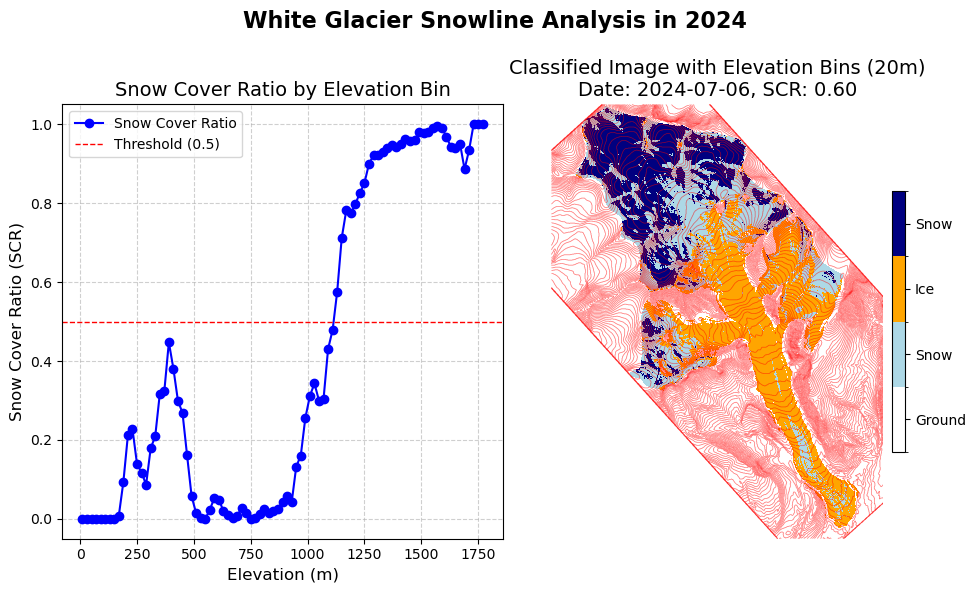

In [345]:
# Bin the elevation data into 20m intervals
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))

# Calculate the mid elevation for each bin for plotting
scr_df['Elevation_Mid'] = scr_df['Elevation_Bin'].apply(
    lambda x: (float(x.split('-')[0]) + float(x.split('-')[1][:-1])) / 2
)


# Plot 1: Snow Cover Ratio vs Elevation
ax1.plot(
    scr_df['Elevation_Mid'],
    scr_df['Snow_Cover_Ratio'],
    marker='o',
    linestyle='-',
    color='blue',
    label='Snow Cover Ratio'
)
# Add a horizontal threshold line at SCR = 0.5
ax1.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Threshold (0.5)')
ax1.set_xlabel('Elevation (m)', fontsize=12)
ax1.set_ylabel('Snow Cover Ratio (SCR)', fontsize=12)
ax1.set_title('Snow Cover Ratio by Elevation Bin', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(fontsize=10)


# Plot 2: Classified Image with Elevation Bins & Contours
# Define a discrete colormap for the classified image
cmap = mcolors.ListedColormap(['white', 'lightblue', 'orange', 'navy'])
bounds = [0, 1, 2, 3, 4]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Plot the classified image
im = ax2.imshow(classified_image, cmap=cmap, norm=norm, interpolation='none')

# Add a colorbar with custom labels (update the labels as necessary)
cbar = plt.colorbar(
    im,
    ax=ax2,
    boundaries=bounds,
    ticks=[0.5, 1.5, 2.5, 3.5],
    shrink=0.6,
    pad=0.02
)
cbar.ax.set_yticklabels(['Ground', 'Snow', 'Ice', 'Snow'], fontsize=10)

# Overlay elevation contours for visualization
for i in range(len(elevation_bins) - 1):
    lower_bound = elevation_bins[i]
    upper_bound = elevation_bins[i + 1]
    # Create a binary mask for areas within the current elevation bin
    elevation_mask = (dem_data >= lower_bound) & (dem_data < upper_bound)
    # Plot contours outlining the elevation bins
    ax2.contour(elevation_mask, levels=[0.5], colors='red', linewidths=0.5, alpha=0.3)

# Remove axis ticks and labels for the image subplot for a cleaner look
ax2.axis('off')
ax2.set_title(
    f'Classified Image with Elevation Bins (20m)\nDate: {lowest_scr_date.date()}, SCR: {lowest_scr_value:.2f}',
    fontsize=14
)


# Final adjustments: Main title and layout

fig.suptitle(
    f'White Glacier Snowline Analysis in {lowest_scr_date.year}',
    fontsize=16,
    fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [346]:
# Define pixel values for snow and ice (update these values as needed)
snow_classes = [1, 3]  # e.g., two different types of snow
ice_classes = [2]      # ice classification value
ground_classes = [0]   # ground class

# Create masks for snow and ice
snow_mask = np.isin(classified_image, snow_classes)
ice_mask = np.isin(classified_image, ice_classes)

# Identify the snow-ice boundary:
# Dilate the ice mask so that adjacent snow pixels can be detected
ice_dilated = morphology.binary_dilation(ice_mask, disk(1))
# The boundary is where snow exists next to ice
snow_ice_boundary = snow_mask & ice_dilated

# Create a glacier mask: snow + ice (exclude ground)
glacier_mask = (np.isin(classified_image, snow_classes + ice_classes)) & (~np.isin(classified_image, ground_classes))

# Erode the glacier mask to remove edge effects (adjust disk size as needed)
glacier_core = morphology.binary_erosion(glacier_mask, disk(10))

# Refine the snow-ice boundary to exclude glacier edges:
# Only keep boundary pixels that are well within the glacier core
refined_snow_ice_boundary = snow_ice_boundary & glacier_core

# Label connected regions in the refined boundary
labeled_boundary = label(refined_snow_ice_boundary)

# Filter out small regions based on a minimum area threshold (e.g., > 100 pixels)
filtered_boundary = np.zeros_like(labeled_boundary, dtype=bool)
for region in regionprops(labeled_boundary):
    if region.area > 100:  # Adjust the threshold based on your needs
        filtered_boundary[labeled_boundary == region.label] = True


# Extract elevations for the refined boundary
boundary_elevations = dem_data[filtered_boundary]

# Remove invalid values (e.g., NaN)
boundary_elevations = boundary_elevations[~np.isnan(boundary_elevations)]

In [347]:
# Compute statistics
average_elevation = np.mean(boundary_elevations)
median_elevation = np.median(boundary_elevations)
std_elevation = np.std(boundary_elevations)

# Find the highest frequency and the related elevation
hist, bin_edges = np.histogram(boundary_elevations, bins=np.arange(boundary_elevations.min(), boundary_elevations.max() + 10, 10))
bin_size = bin_edges[1] - bin_edges[0]
print(f"Bin size: {bin_size}")
max_freq_index = np.argmax(hist)
max_freq_elevation = (bin_edges[max_freq_index] + bin_edges[max_freq_index + 1]) / 2

print(f"Average Snow Line Elevation: {average_elevation:.2f} m")
print(f"Median Elevation: {median_elevation:.2f} m")
print(f"Standard Deviation: {std_elevation:.2f} m")
print(f"Highest Frequency: {hist[max_freq_index]} at Elevation: {max_freq_elevation:.2f} m")

Bin size: 10.0
Average Snow Line Elevation: 932.66 m
Median Elevation: 1072.96 m
Standard Deviation: 323.21 m
Highest Frequency: 382 at Elevation: 1121.95 m


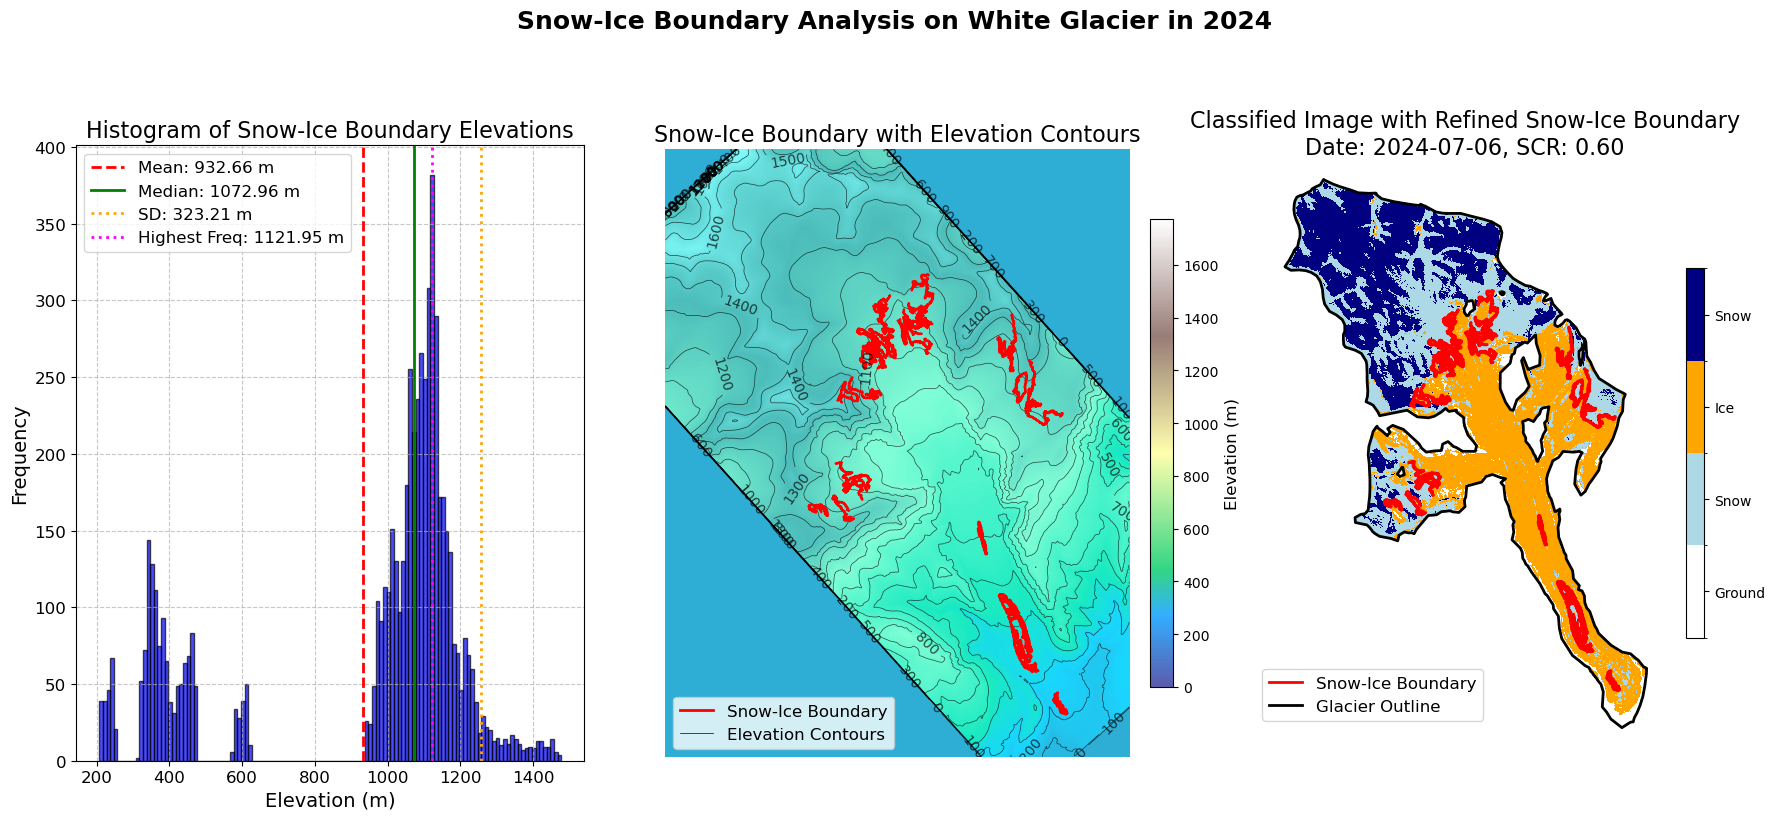

In [348]:
# Snow-Ice Boundary Elevation Histogram
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Subplot 1: Histogram of Snow-Ice Boundary Elevations
axes[0].hist(boundary_elevations, bins=bin_edges, color='blue', edgecolor='black', alpha=0.7)
axes[0].axvline(average_elevation, color='red', linestyle='--', linewidth=2,
                label=f'Mean: {average_elevation:.2f} m')
axes[0].axvline(median_elevation, color='green', linestyle='-', linewidth=2,
                label=f'Median: {median_elevation:.2f} m')
axes[0].axvline(average_elevation + std_elevation, color='orange', linestyle=':', linewidth=2,
                label=f'SD: {std_elevation:.2f} m')
axes[0].axvline(max_freq_elevation, color='magenta', linestyle=':', linewidth=2,
                label=f'Highest Freq: {max_freq_elevation:.2f} m')
axes[0].set_xlabel('Elevation (m)', fontsize=14)
axes[0].set_ylabel('Frequency', fontsize=14)
axes[0].set_title('Histogram of Snow-Ice Boundary Elevations', fontsize=16)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].tick_params(axis='both', which='major', labelsize=12)
axes[0].legend(fontsize=12)


# Subplot 2: DEM with Snow-Ice Boundary & Elevation Contours
# Plot the DEM image only once and store the handle for the colorbar
dem_im = axes[1].imshow(dem_data, cmap='terrain', alpha=0.8)
# Overlay the filtered snow-ice boundary with some transparency
axes[1].imshow(filtered_boundary, cmap='cool', alpha=0.5)
# Plot elevation contours on the DEM
contours = axes[1].contour(dem_data, levels=20, colors='black', linewidths=0.5, alpha=0.7)
axes[1].clabel(contours, inline=True, fontsize=10, fmt='%1.0f', colors='black')
# Highlight the snow-ice boundary with a thicker red contour
boundary_contour = axes[1].contour(filtered_boundary, levels=[0.5], colors='red', linewidths=1.5)
# Create a combined legend using custom handles
legend_elements = [
    plt.Line2D([0], [0], color='red', lw=2, label='Snow-Ice Boundary'),
    plt.Line2D([0], [0], color='black', lw=0.5, label='Elevation Contours')
]
axes[1].legend(handles=legend_elements, fontsize=12, loc='lower left')
axes[1].set_title("Snow-Ice Boundary with Elevation Contours", fontsize=16)
axes[1].axis('off')
# Add a colorbar for the DEM image using the stored handle
cbar = fig.colorbar(dem_im, ax=axes[1], orientation='vertical',
                    fraction=0.046, pad=0.04, shrink=0.8)
cbar.set_label('Elevation (m)', fontsize=12)
cbar.ax.tick_params(labelsize=10)


# Subplot 3: Classified Image with Refined Snow-Ice Boundary
# 1) Define a discrete colormap & normalization for the classified image
cmap = mcolors.ListedColormap(['white', 'lightblue', 'orange', 'navy'])
bounds = [0, 1, 2, 3, 4]  # class boundaries: 0,1,2,3,4
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# 2) Show the classified image
im_class = axes[2].imshow(classified_image, cmap=cmap, norm=norm, extent=extent, origin='upper', interpolation='none')

# 3) Add a colorbar for the classified image
cbar_class = plt.colorbar(im_class, ax=axes[2], boundaries=bounds,
                          ticks=[0.5, 1.5, 2.5, 3.5], shrink=0.6, pad=0.02)
cbar_class.ax.set_yticklabels(['Ground', 'Snow', 'Ice', 'Snow'], fontsize=10)

# 4) Overlay the refined snow-ice boundary as a contour line
x_coords = np.linspace(extent[0], extent[1], classified_image.shape[1])
y_coords = np.linspace(extent[3], extent[2], classified_image.shape[0])  # if origin='upper'
X, Y = np.meshgrid(x_coords, y_coords)
axes[2].contour(X, Y, filtered_boundary, levels=[0.5], colors='red', linewidths=2)

# 5) Overlay the glacier outline
glacier_outline.plot(ax=axes[2], facecolor='none', edgecolor='black', linewidth=2, zorder=3)

# 6) Create a legend handle for the boundary (contour lines do not auto-legend)
boundary_line = mlines.Line2D([], [], color='red', linewidth=2, label='Snow-Ice Boundary')
outline_line = mlines.Line2D([], [], color='black', linewidth=2, label='Glacier Outline')
axes[2].legend(handles=[boundary_line, outline_line], fontsize=12, loc='lower left')

# 7) Title and remove axis ticks
axes[2].set_title(
    f'Classified Image with Refined Snow-Ice Boundary\nDate: {lowest_scr_date.date()}, SCR: {lowest_scr_value:.2f}',
    fontsize=16
)
axes[2].axis('off')
# Overall Figure Title and Layout Adjustments

plt.suptitle(f'Snow-Ice Boundary Analysis on White Glacier in {lowest_scr_date.year}',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [349]:
# Define acceptable elevation range for the primary snowline
elevation_min = 900  # Lower bound for snowline

# Filter the boundary elevations to exclude outliers
filtered_elevations = boundary_elevations[
    (boundary_elevations >= elevation_min) 
]

# Create a mask for elevations below 900m
elevation_mask_below_900 = dem_data < elevation_min

# Remove the boundary below 900m
filtered_boundary[elevation_mask_below_900] = False

In [350]:
# Compute statistics
average_elevation = np.mean(filtered_elevations)
median_elevation = np.median(filtered_elevations)
std_elevation = np.std(filtered_elevations)

# Find the highest frequency and the related elevation
hist, bin_edges = np.histogram(filtered_elevations, bins=np.arange(filtered_elevations.min(), filtered_elevations.max() + 5, 5))
bin_size = bin_edges[1] - bin_edges[0]
print(f"Bin size: {bin_size}")
max_freq_index = np.argmax(hist)
max_freq_elevation = (bin_edges[max_freq_index] + bin_edges[max_freq_index + 1]) / 2

print(f"Average Snow Line Elevation: {average_elevation:.2f} m")
print(f"Median Elevation: {median_elevation:.2f} m")
print(f"Standard Deviation: {std_elevation:.2f} m")
print(f"Highest Frequency: {hist[max_freq_index]} at Elevation: {max_freq_elevation:.2f} m")

Bin size: 5.0
Average Snow Line Elevation: 1109.65 m
Median Elevation: 1105.67 m
Standard Deviation: 88.39 m
Highest Frequency: 194 at Elevation: 1122.27 m


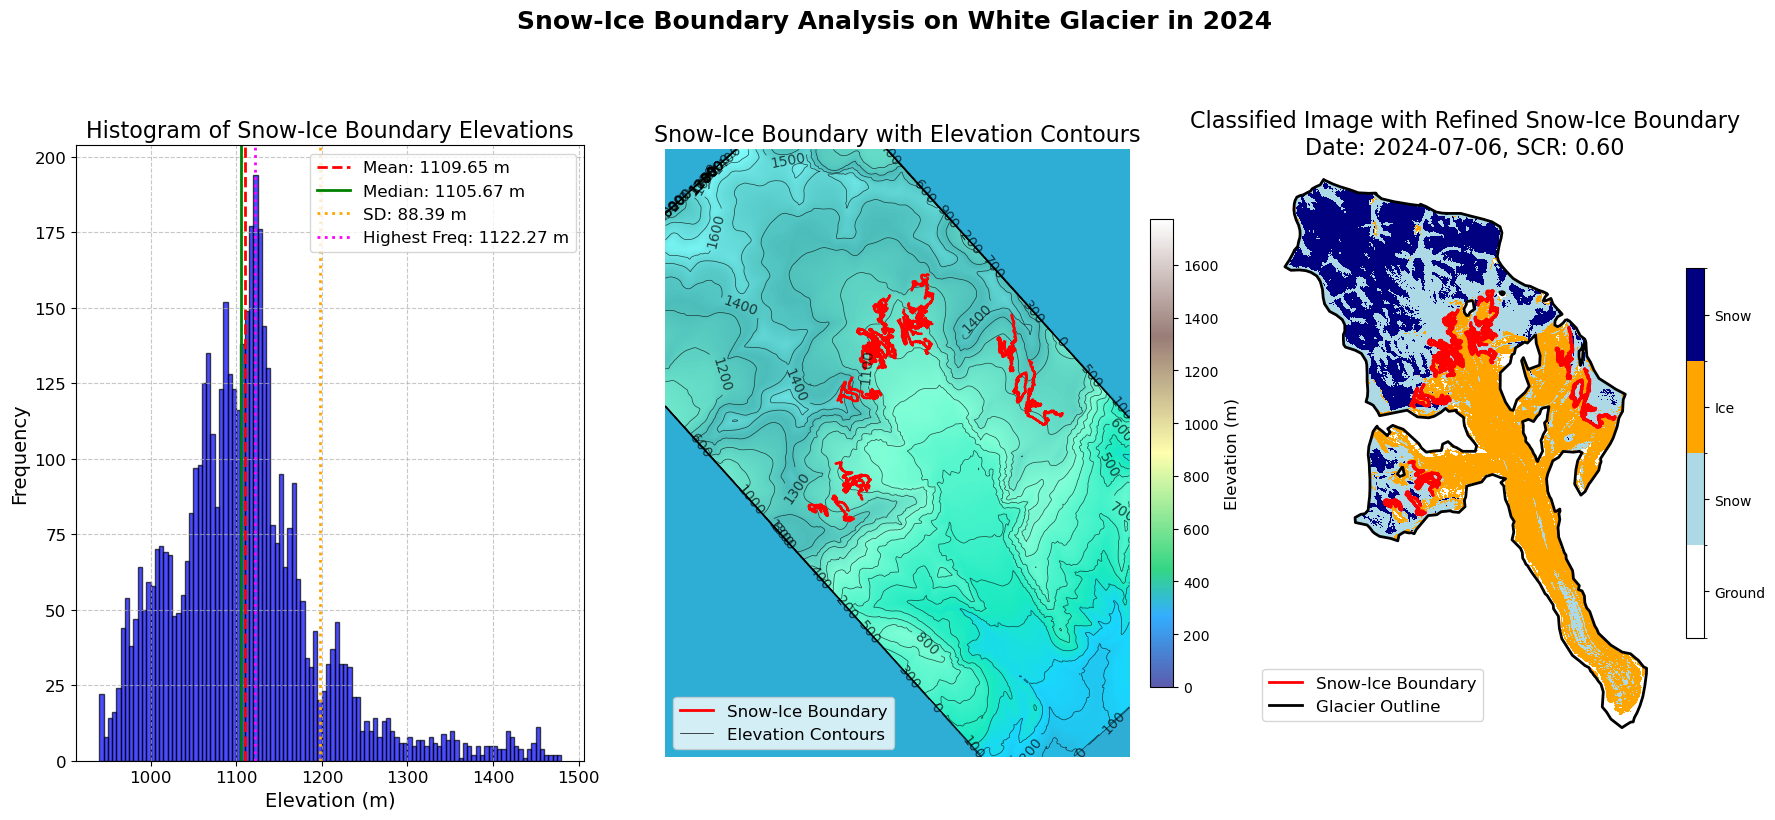

In [351]:
# snow-ice boundary elevation histogram
fig, axes = plt.subplots(1, 3, figsize=(18, 8))


# Subplot 1: Histogram of Snow-Ice Boundary Elevations

axes[0].hist(filtered_elevations, bins=bin_edges, color='blue', edgecolor='black', alpha=0.7)
axes[0].axvline(average_elevation, color='red', linestyle='--', linewidth=2,
                label=f'Mean: {average_elevation:.2f} m')
axes[0].axvline(median_elevation, color='green', linestyle='-', linewidth=2,
                label=f'Median: {median_elevation:.2f} m')
axes[0].axvline(average_elevation + std_elevation, color='orange', linestyle=':', linewidth=2,
                label=f'SD: {std_elevation:.2f} m')
axes[0].axvline(max_freq_elevation, color='magenta', linestyle=':', linewidth=2,
                label=f'Highest Freq: {max_freq_elevation:.2f} m')
axes[0].set_xlabel('Elevation (m)', fontsize=14)
axes[0].set_ylabel('Frequency', fontsize=14)
axes[0].set_title('Histogram of Snow-Ice Boundary Elevations', fontsize=16)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].tick_params(axis='both', which='major', labelsize=12)
axes[0].legend(fontsize=12)


# Subplot 2: DEM with Snow-Ice Boundary & Elevation Contours
# Plot the DEM image only once and store the handle for the colorbar
dem_im = axes[1].imshow(dem_data, cmap='terrain', alpha=0.8)
# Overlay the filtered snow-ice boundary with some transparency
axes[1].imshow(filtered_boundary, cmap='cool', alpha=0.5)
# Plot elevation contours on the DEM
contours = axes[1].contour(dem_data, levels=20, colors='black', linewidths=0.5, alpha=0.7)
axes[1].clabel(contours, inline=True, fontsize=10, fmt='%1.0f', colors='black')
# Highlight the snow-ice boundary with a thicker red contour
boundary_contour = axes[1].contour(filtered_boundary, levels=[0.5], colors='red', linewidths=1.5)
# Create a combined legend using custom handles
legend_elements = [
    plt.Line2D([0], [0], color='red', lw=2, label='Snow-Ice Boundary'),
    plt.Line2D([0], [0], color='black', lw=0.5, label='Elevation Contours')
]
axes[1].legend(handles=legend_elements, fontsize=12, loc='lower left')
axes[1].set_title("Snow-Ice Boundary with Elevation Contours", fontsize=16)
axes[1].axis('off')
# Add a colorbar for the DEM image using the stored handle
cbar = fig.colorbar(dem_im, ax=axes[1], orientation='vertical',
                    fraction=0.046, pad=0.04, shrink=0.8)
cbar.set_label('Elevation (m)', fontsize=12)
cbar.ax.tick_params(labelsize=10)


# Subplot 3: Classified Image with Refined Snow-Ice Boundary
# 1) Define a discrete colormap & normalization for the classified image
cmap = mcolors.ListedColormap(['white', 'lightblue', 'orange', 'navy'])
bounds = [0, 1, 2, 3, 4]  # class boundaries: 0,1,2,3,4
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# 2) Show the classified image
im_class = axes[2].imshow(classified_image, cmap=cmap, norm=norm, extent=extent, origin='upper', interpolation='none')

# 3) Add a colorbar for the classified image
cbar_class = plt.colorbar(im_class, ax=axes[2], boundaries=bounds,
                          ticks=[0.5, 1.5, 2.5, 3.5], shrink=0.6, pad=0.02)
cbar_class.ax.set_yticklabels(['Ground', 'Snow', 'Ice', 'Snow'], fontsize=10)

# 4) Overlay the refined snow-ice boundary as a contour line
x_coords = np.linspace(extent[0], extent[1], classified_image.shape[1])
y_coords = np.linspace(extent[3], extent[2], classified_image.shape[0])  # if origin='upper'
X, Y = np.meshgrid(x_coords, y_coords)
axes[2].contour(X, Y, filtered_boundary, levels=[0.5], colors='red', linewidths=2)

# 5) Overlay the glacier outline
glacier_outline.plot(ax=axes[2], facecolor='none', edgecolor='black', linewidth=2, zorder=3)

# 6) Create a legend handle for the boundary (contour lines do not auto-legend)
boundary_line = mlines.Line2D([], [], color='red', linewidth=2, label='Snow-Ice Boundary')
outline_line = mlines.Line2D([], [], color='black', linewidth=2, label='Glacier Outline')
axes[2].legend(handles=[boundary_line, outline_line], fontsize=12, loc='lower left')

# 7) Title and remove axis ticks
axes[2].set_title(
    f'Classified Image with Refined Snow-Ice Boundary\nDate: {lowest_scr_date.date()}, SCR: {lowest_scr_value:.2f}',
    fontsize=16
)
axes[2].axis('off')

# Overall Figure Title and Layout Adjustments

plt.suptitle(f'Snow-Ice Boundary Analysis on White Glacier in {lowest_scr_date.year}',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
